In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import json

RAW       = Path("data/raw")
label_dir = RAW / "label"
device    = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

# ── Helper: match image to its label ──────────────────────────────────────────
def pair_image_label(img_path, label_dir):
    stem       = img_path.stem.replace("_nonorm_bands20m", "")
    label_path = Path(label_dir) / f"{stem}_bin_label.tiff"
    return label_path if label_path.exists() else None

# ── Dataset class ──────────────────────────────────────────────────────────────
class MethaneSegDataset(Dataset):
    def __init__(self, dataframe, label_dir):
        self.df        = dataframe.reset_index(drop=True)
        self.label_dir = Path(label_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = row["path"]
        lbl_path = pair_image_label(img_path, self.label_dir)

        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float32)

        b11  = img[11]
        b12  = img[12]
        eps  = 1e-6

        def norm(x):
            lo, hi = np.percentile(x, 2), np.percentile(x, 98)
            return np.clip((x - lo) / (hi - lo + eps), 0, 1).astype(np.float32)

        b11_n = norm(b11)
        b12_n = norm(b12)
        ratio = np.clip((b12_n + eps) / (b11_n + eps), 0, 5).astype(np.float32)
        diff  = (b12_n - b11_n).astype(np.float32)
        x     = np.stack([b11_n, b12_n, ratio, diff], axis=0)

        with rasterio.open(lbl_path) as src:
            lbl  = src.read(1).astype(np.float32)
        mask = (lbl > 0.5).astype(np.float32)

        return (
            torch.tensor(x,    dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        )

print("pair_image_label and MethaneSegDataset defined")

Device: mps
pair_image_label and MethaneSegDataset defined


In [22]:
all_files = sorted(RAW.glob("*.tiff"))
records = []
for f in all_files:
    stem       = f.stem
    main_parts = stem.split("___")
    sample_id  = int(main_parts[0])
    rest       = main_parts[1].split("_")
    loc_id     = int(rest[0])
    records.append({"path": f, "sample_id": sample_id, "location_id": loc_id})

meta_df  = pd.DataFrame(records)
train_df = meta_df[meta_df["location_id"].isin([0,1,2,3,4,5,6,7])].reset_index(drop=True)
val_df   = meta_df[meta_df["location_id"].isin([8,9])].reset_index(drop=True)

train_loader = DataLoader(MethaneSegDataset(train_df, label_dir), batch_size=2, shuffle=True,  num_workers=0)
val_loader   = DataLoader(MethaneSegDataset(val_df,   label_dir), batch_size=2, shuffle=False, num_workers=0)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 619 | Val: 185


In [24]:
all_files = sorted(RAW.glob("*.tiff"))
records   = []
for f in all_files:
    main = f.stem.split("___")
    records.append({
        "path"       : f,
        "sample_id"  : int(main[0]),
        "location_id": int(main[1].split("_")[0])
    })

meta_df  = pd.DataFrame(records)
val_df   = meta_df[meta_df["location_id"].isin([8,9])].reset_index(drop=True)
val_dataset = MethaneSegDataset(val_df, label_dir)
val_loader  = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
print(f"Val set: {len(val_dataset)} tiles")

Val set: 185 tiles


In [26]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class TinyUNet(nn.Module):
    def __init__(self, in_channels=4, filters=[16,32,64,128]):
        super().__init__()
        f = filters
        self.enc1 = DoubleConv(in_channels, f[0])
        self.enc2 = DoubleConv(f[0], f[1])
        self.enc3 = DoubleConv(f[1], f[2])
        self.enc4 = DoubleConv(f[2], f[3])
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(f[3], f[3]*2)
        self.up4  = nn.ConvTranspose2d(f[3]*2, f[3], 2, stride=2)
        self.dec4 = DoubleConv(f[3]*2, f[3])
        self.up3  = nn.ConvTranspose2d(f[3], f[2], 2, stride=2)
        self.dec3 = DoubleConv(f[2]*2, f[2])
        self.up2  = nn.ConvTranspose2d(f[2], f[1], 2, stride=2)
        self.dec2 = DoubleConv(f[1]*2, f[1])
        self.up1  = nn.ConvTranspose2d(f[1], f[0], 2, stride=2)
        self.dec1 = DoubleConv(f[0]*2, f[0])
        self.out  = nn.Conv2d(f[0], 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)

# Load saved checkpoint
model = TinyUNet(in_channels=4).to(device, dtype=torch.float32)
checkpoint_path = "outputs/checkpoints/tiny_unet_epoch15.pt"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
print(f" Loaded checkpoint: {checkpoint_path}")

 Loaded checkpoint: outputs/checkpoints/tiny_unet_epoch15.pt


In [28]:
all_tp = all_fp = all_fn = all_tn = 0
eps = 1e-6

with torch.no_grad():
    for x, mask in val_loader:
        x    = x.to(device, dtype=torch.float32)
        mask = mask.to(device, dtype=torch.float32)
        pred_logits = model(x)
        pred = (torch.sigmoid(pred_logits) > 0.5).float()

        pred_np = pred.cpu().squeeze().numpy()
        gt_np   = mask.cpu().squeeze().numpy()

        all_tp += ((pred_np==1) & (gt_np==1)).sum()
        all_fp += ((pred_np==1) & (gt_np==0)).sum()
        all_fn += ((pred_np==0) & (gt_np==1)).sum()
        all_tn += ((pred_np==0) & (gt_np==0)).sum()

# Compute all metrics from global TP/FP/FN/TN
precision = all_tp / (all_tp + all_fp + eps)
recall    = all_tp / (all_tp + all_fn + eps)
f1        = 2 * precision * recall / (precision + recall + eps)
iou       = all_tp / (all_tp + all_fp + all_fn + eps)
fp_rate   = all_fp / (all_fp + all_tn + eps)
accuracy  = (all_tp + all_tn) / (all_tp + all_fp + all_fn + all_tn + eps)

print("=" * 45)
print("   TinyUNet Full Evaluation — Val Set")
print("=" * 45)
print(f"  Precision  : {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall     : {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1 Score   : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  IoU        : {iou:.4f}  ({iou*100:.1f}%)")
print(f"  FP Rate    : {fp_rate:.4f}  ({fp_rate*100:.1f}%)")
print(f"  Accuracy   : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print("=" * 45)
print(f"\n  Physics baseline F1  : 0.2080  (20.8%)")
print(f"  TinyUNet F1          : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  Improvement          : {f1/0.2080:.1f}× over physics baseline")

   TinyUNet Full Evaluation — Val Set
  Precision  : 0.7565  (75.7%)
  Recall     : 0.5813  (58.1%)
  F1 Score   : 0.6575  (65.7%)
  IoU        : 0.4897  (49.0%)
  FP Rate    : 0.0010  (0.1%)
  Accuracy   : 0.9969  (99.7%)

  Physics baseline F1  : 0.2080  (20.8%)
  TinyUNet F1          : 0.6575  (65.7%)
  Improvement          : 3.2× over physics baseline


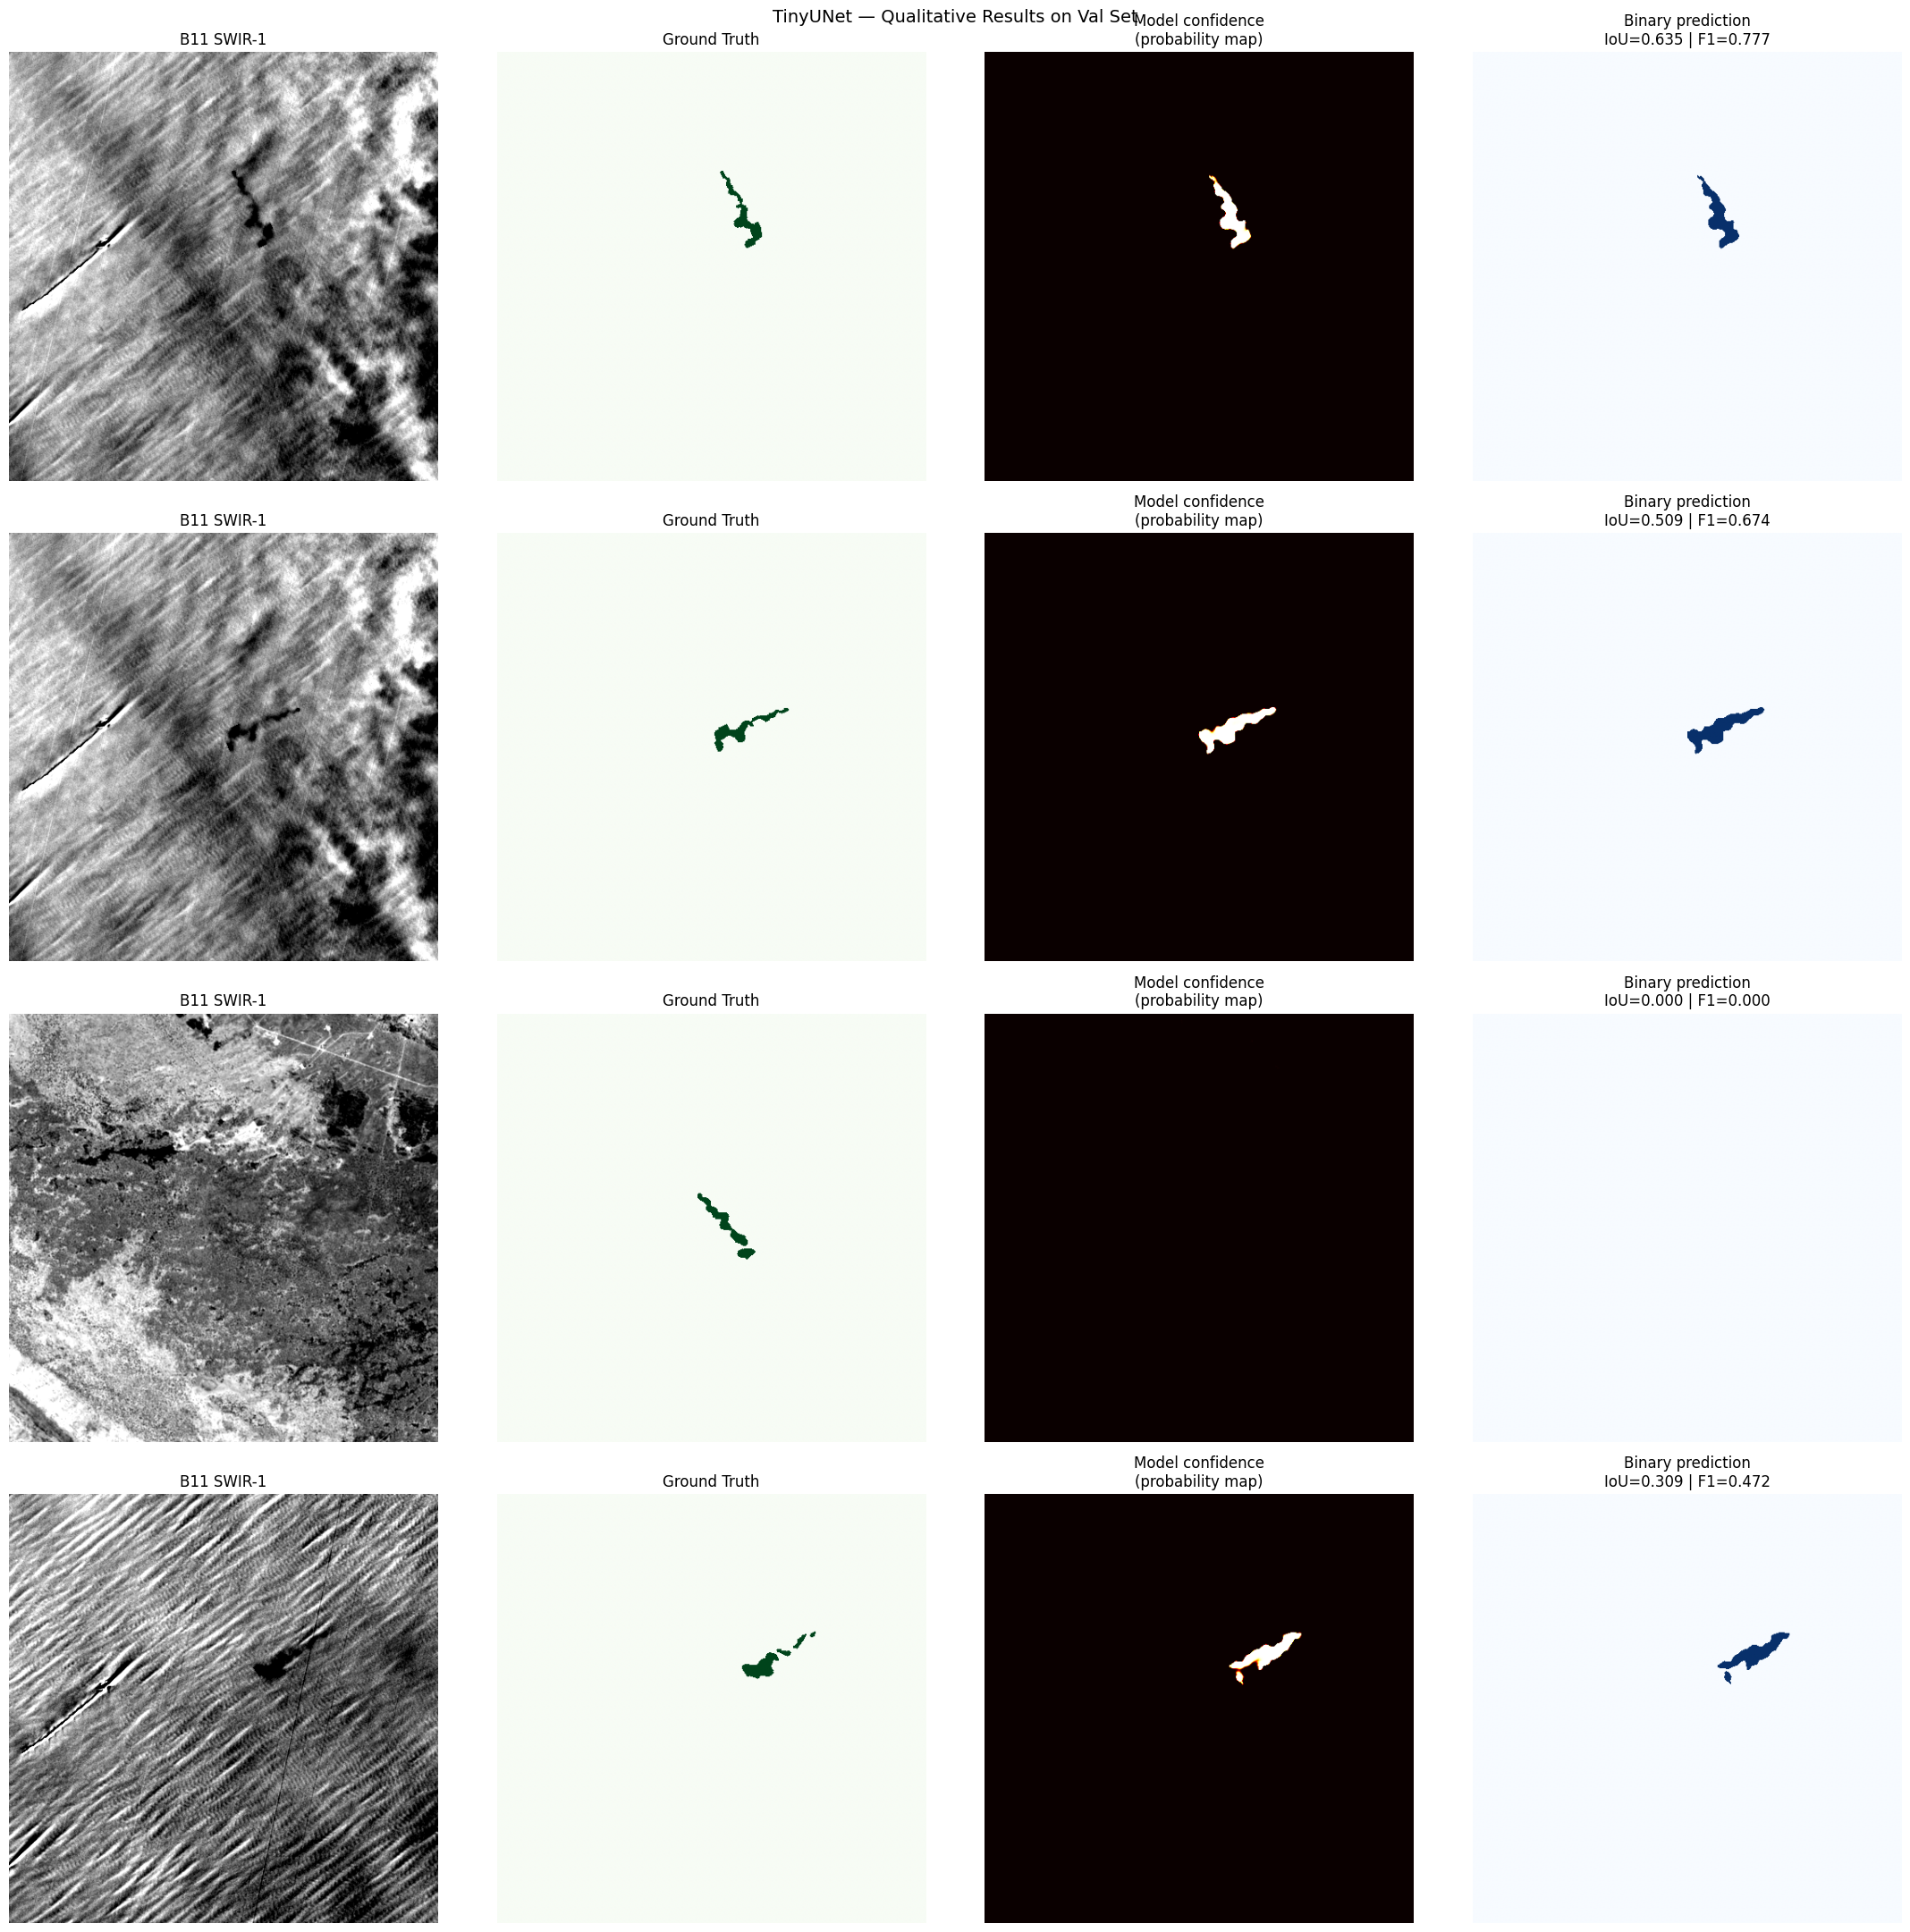

In [30]:
fig, axes = plt.subplots(4, 4, figsize=(22, 22))

for row, idx in enumerate([0, 40, 80, 120]):
    x, mask = val_dataset[idx]
    gt = mask.squeeze().numpy()

    with torch.no_grad():
        x_in  = x.unsqueeze(0).to(device, dtype=torch.float32)
        logits = model(x_in)
        prob   = torch.sigmoid(logits).cpu().squeeze().numpy()
        pred   = (prob > 0.5).astype(np.float32)

    tp = ((pred==1)&(gt==1)).sum()
    fp = ((pred==1)&(gt==0)).sum()
    fn = ((pred==0)&(gt==1)).sum()
    tile_iou = tp / (tp+fp+fn+1e-6)
    tile_f1  = 2*tp / (2*tp+fp+fn+1e-6)

    axes[row,0].imshow(x[0].numpy(), cmap="gray")
    axes[row,0].set_title("B11 SWIR-1")

    axes[row,1].imshow(gt, cmap="Greens")
    axes[row,1].set_title("Ground Truth")

    axes[row,2].imshow(prob, cmap="hot", vmin=0, vmax=1)
    axes[row,2].set_title("Model confidence\n(probability map)")

    axes[row,3].imshow(pred, cmap="Blues")
    axes[row,3].set_title(f"Binary prediction\nIoU={tile_iou:.3f} | F1={tile_f1:.3f}")

for ax in axes.flat: ax.axis("off")
plt.suptitle("TinyUNet — Qualitative Results on Val Set", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/figures/tinyunet_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
metrics = {
    "model"       : "TinyUNet",
    "checkpoint"  : checkpoint_path,
    "val_tiles"   : len(val_dataset),
    "precision"   : round(float(precision), 4),
    "recall"      : round(float(recall),    4),
    "f1_score"    : round(float(f1),        4),
    "iou"         : round(float(iou),       4),
    "fp_rate"     : round(float(fp_rate),   4),
    "accuracy"    : round(float(accuracy),  4),
    "vs_physics_baseline_f1": round(float(f1/0.2080), 2)
}

with open("outputs/tinyunet_eval_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved to outputs/tinyunet_eval_metrics.json")
print(json.dumps(metrics, indent=2))

Saved to outputs/tinyunet_eval_metrics.json
{
  "model": "TinyUNet",
  "checkpoint": "outputs/checkpoints/tiny_unet_epoch15.pt",
  "val_tiles": 185,
  "precision": 0.7565,
  "recall": 0.5813,
  "f1_score": 0.6575,
  "iou": 0.4897,
  "fp_rate": 0.001,
  "accuracy": 0.9969,
  "vs_physics_baseline_f1": 3.16
}
